<a href="https://colab.research.google.com/github/hirenpatel1404/assignment-9-unsupervised/blob/main/Assignment_9_Unsupervised_Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Hiren Patel
##Assignment 9: Unsupervised Learning
###Mall Customer Segmentation dataset

#Introduction
For this assignement I am using the Mall Customer Segmentation dataset. It contains information about 200 customers who visit a shopping mall, including their gender, age, annual income, and a spending score that the mall assigns based on their spending behaviour.

This is an unsupervised learning task. That means the data has no target column and no "right answer" to predict. Instead of predicting a label, my goal is to discover natural groups (segments) of customers who are similar to each other, based on their income, spending, and age.

The problem I am solving is customer segmentation: I want to find out whether the mall's customers naturally fall into distinct groups, so that each group can be understood and targeted differently. For example, some customers may earn a lot but spend little, while others may earn less but spend a lot. Identifying these segments helps a marketing team tailor its campaigns to each type of customer instead of treating everyone the same.

My objectives are:
1. Use clustering (K-means and Hierarchical) to group customers into meaningful segments.
2. Find the best number of clusters using the Elbow method and Silhouette score.
3. Use dimensionality reduction (PCA) to visualise the customers in a simple 2D plot.
4. Interpret each segment so a marketing team could act on it.

DataSet link - https://www.kaggle.com/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python

#Import libraries


In [3]:
# I import the core data-handling libraries.
import numpy as np
import pandas as pd

# I import my plotting libraries for the charts.
import matplotlib.pyplot as plt
import seaborn as sns

# I import the scaling tool — clustering is distance-based, so scaling matters a lot here.
from sklearn.preprocessing import StandardScaler

# I import my two clustering methods.
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering

# I import PCA for dimensionality reduction (to visualise the data in 2D).
from sklearn.decomposition import PCA

# I import the silhouette score — my main evaluation metric for clustering.
from sklearn.metrics import silhouette_score

# I import scipy's dendrogram tools for the hierarchical clustering tree.
from scipy.cluster.hierarchy import dendrogram, linkage


#Step 2 — Load the data

In [4]:
# I load the CSV file into a pandas DataFrame (a table I can work with).
df = pd.read_csv("Mall_Customers.csv")

# I check the size: how many rows (customers) and columns I have.
print("My dataset has", df.shape[0], "rows and", df.shape[1], "columns.")

# I print the first 5 rows, forcing all columns to show.
print(df.head().to_string())

My dataset has 200 rows and 5 columns.
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40


In [5]:
# I check the data types and how many non-empty values each column has.
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [6]:
# I count any missing values per column.
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


###Interpretation
In this step I loaded the dataset and took my first look at it. I checked its size, viewed the first few rows, and inspected the data types and missing values.

I did this because before any analysis I need to understand the raw data: what columns exist, what type each one is, and whether anything needs cleaning. This shapes the preprocessing steps that follow.

The outcome is that the dataset has 200 customers and 5 columns: a CustomerID, Gender (text), Age, Annual Income, and Spending Score. There are no missing values, so no filling is needed. The only text column is Gender, which I will convert to a number later, and CustomerID is just an identifier that I will not use for clustering.

#Step 3 —  EDA

In [7]:
# I look at the summary stats (min, max, mean, etc.) of my numeric columns.
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


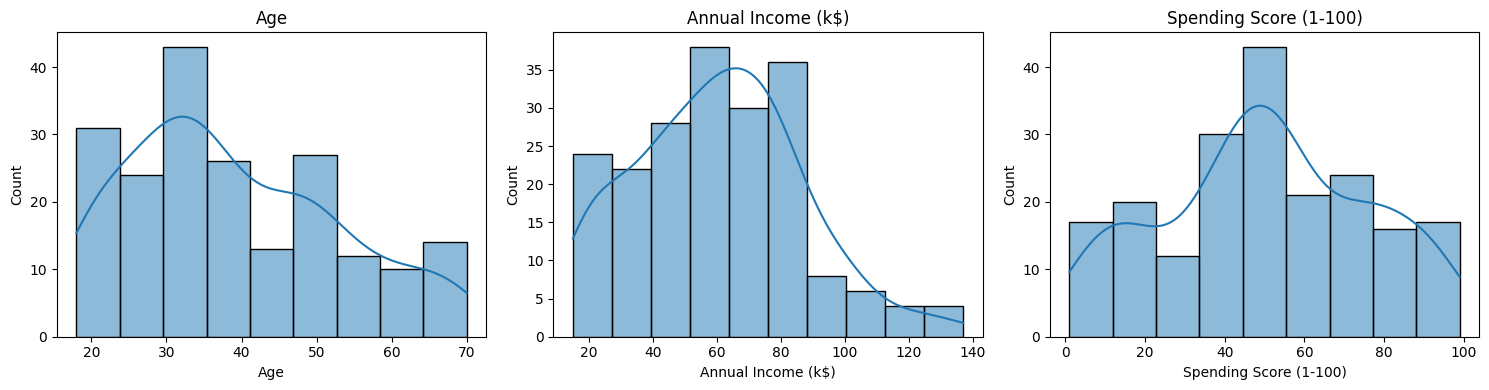

In [8]:
# I plot the distribution of Age, Annual Income, and Spending Score to see their spread.
features = ["Age", "Annual Income (k$)", "Spending Score (1-100)"]

plt.figure(figsize=(15, 4))
for i, col in enumerate(features):
    plt.subplot(1, 3, i + 1)
    sns.histplot(df[col], kde=True)
    plt.title(col)
plt.tight_layout()
plt.show()

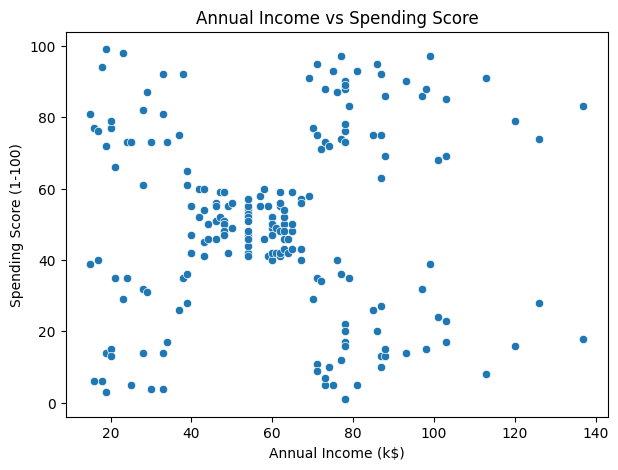

In [9]:
# I plot Annual Income against Spending Score — this is the relationship segmentation usually reveals.
plt.figure(figsize=(7, 5))
sns.scatterplot(x="Annual Income (k$)", y="Spending Score (1-100)", data=df)
plt.title("Annual Income vs Spending Score")
plt.show()

###Interpretation
In this step I explored the data before clustering. I looked at the summary statistics, plotted the distributions of Age, Annual Income and Spending Score, and then plotted Annual Income against Spending Score.

I did this to understand the spread of each feature and to look for any natural structure in the data before applying any algorithm. Seeing the shape of the data helps me anticipate how many segments might exist and lets me sense-check my clustering results later.

Discussing the outcome of the plots:
- The three histograms show that customers vary a lot. Age is skewed towards younger customers, with most people in their twenties, thirties and forties and fewer older customers. Annual Income is fairly spread out and roughly centred in the middle of the range, with a smaller number of very high earners. Spending Score is spread across the whole 1-100 range and clusters loosely around the middle, showing that spending habits differ widely.
- The scatter plot of Annual Income against Spending Score is the most revealing. Instead of forming one single cloud, the points visibly separate into several distinct groups: customers with low income and low spending, low income and high spending, average income and average spending, high income and low spending, and high income and high spending.

The outcome is that the data clearly contains natural structure, especially in the income-versus-spending view where about five loose groups can already be seen by eye. This strongly suggests the customers do fall into distinct segments, which is exactly what my clustering step will now try to identify formally.

#Step 4 — Preprocessing

In [10]:
# I drop CustomerID because it is just an identifier and carries no meaning for grouping.
# I keep the features that describe the customer.
data = df.drop(columns=["CustomerID"]).copy()

# I convert Gender from text into a number (Male = 0, Female = 1), because the maths needs numbers.
data["Gender"] = data["Gender"].map({"Male": 0, "Female": 1})

print("My data after encoding Gender:")
print(data.head().to_string())

My data after encoding Gender:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       0   19                  15                      39
1       0   21                  15                      81
2       1   20                  16                       6
3       1   23                  16                      77
4       1   31                  17                      40


In [11]:
# I scale all features so they are on the same range (mean 0, similar spread).
# This is essential for clustering, which is based on distances between points.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)

# I keep it as a DataFrame so I can read the column names later.
X_scaled = pd.DataFrame(X_scaled, columns=data.columns)

print("My scaled features (now all on a similar scale):")
print(X_scaled.head().to_string())

My scaled features (now all on a similar scale):
     Gender       Age  Annual Income (k$)  Spending Score (1-100)
0 -1.128152 -1.424569           -1.738999               -0.434801
1 -1.128152 -1.281035           -1.738999                1.195704
2  0.886405 -1.352802           -1.700830               -1.715913
3  0.886405 -1.137502           -1.700830                1.040418
4  0.886405 -0.563369           -1.662660               -0.395980


#Interpretation
In this step I prepared my data for clustering. I dropped the CustomerID column because it is only an identifier and has no meaning for grouping customers. I converted the Gender column from text into a number so the algorithms can use it. Finally, I scaled all the features so they share the same range.

I did this because clustering algorithms work by measuring the distance between data points. If I left the features on their original scales, a feature with large values like Annual Income would dominate the distance calculation and unfairly outweigh a feature with smaller values like Spending Score. Scaling puts every feature on an equal footing so each contributes fairly to the grouping.

The outcome is a clean, fully numeric, scaled dataset where every feature has equal weight, which is exactly what my clustering algorithms need to produce fair and meaningful segments.

#Step 5 — K-means clustering + the Elbow method

In [12]:
# I test K from 1 to 10 and record the "inertia" for each.
# Inertia = how far points are from their cluster centre. Lower = tighter clusters.
inertia = []
K_range = range(1, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state= 42, n_init=10)  # I build a K-means with k clusters
    km.fit(X_scaled)                                                 # I fit it on my scaled data
    inertia.append(km.inertia_)

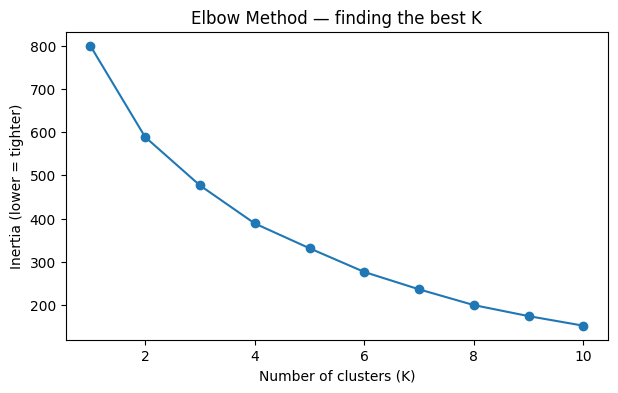

In [13]:
# I plot inertia against K to find the "elbow".
plt.figure(figsize=(7, 4))
plt.plot(K_range, inertia, marker="o")
plt.xlabel("Number of clusters (K)")
plt.ylabel("Inertia (lower = tighter)")
plt.title("Elbow Method — finding the best K")
plt.show()

In [14]:
# I run K-means with the K I picked from the elbow (I'll use 5 here — adjust if your elbow differs).
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
# this gives each customer a cluster number (0–4)
kmeans_labels = kmeans.fit_predict(X_scaled)
# I attach the cluster label back to my original data so I can read the segments.
df["KMeans_Cluster"] = kmeans_labels
print("I assigned each customer to one of 5 clusters.")
print(df["KMeans_Cluster"].value_counts())

I assigned each customer to one of 5 clusters.
KMeans_Cluster
3    54
2    43
0    39
4    35
1    29
Name: count, dtype: int64


###Interpretation
In this step I applied K-means clustering. Because K-means requires me to choose the number of clusters in advance, I first used the Elbow method to find a good value. I ran K-means for every K from 1 to 10 and recorded the inertia each time. Inertia measures how tightly the points sit around their cluster centre, so lower inertia means tighter, better-defined clusters.

I did this because choosing the number of clusters is the most important decision in K-means, and picking it by eye alone would be unreliable. The Elbow method gives me a more principled way to choose.

Discussing the outcome of the plot:
The elbow plot shows the inertia falling quickly at the start, from K=1 to about K=3, and then continuing to decline more gently without a sharp corner. Rather than one dramatic bend, the curve flattens gradually, and the biggest gains have mostly been used up by around K=4 to K=5. This smooth shape is expected here because I am clustering on all four features, which tends to blur the elbow compared with using only two features.

The outcome is that the elbow points to roughly 4 to 5 clusters as a sensible range, but it is not sharp enough to fix the exact number on its own. I therefore treat K=5 as my working choice and confirm it using the Silhouette score in the next step. I ran K-means with 5 clusters, which assigned every customer to one of five segments that I will visualise and interpret shortly.

#Step 6 — Silhouette score

In [16]:
# I test K from 2 to 10 (silhouette needs at least 2 clusters) and record the score for each.
sil_scores = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)                     # I get the cluster labels
    score = silhouette_score(X_scaled, labels)            # I measure how well-separated they are
    sil_scores.append(score)
    print(f"K = {k}  ->  silhouette score = {score:.3f}")

K = 2  ->  silhouette score = 0.252
K = 3  ->  silhouette score = 0.260
K = 4  ->  silhouette score = 0.298
K = 5  ->  silhouette score = 0.304
K = 6  ->  silhouette score = 0.331
K = 7  ->  silhouette score = 0.357
K = 8  ->  silhouette score = 0.388
K = 9  ->  silhouette score = 0.403
K = 10  ->  silhouette score = 0.421


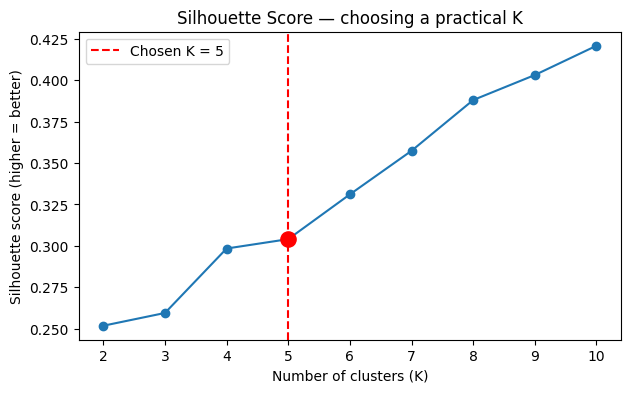

Silhouette score at my chosen K = 5 is 0.304


In [18]:
# I do NOT blindly pick the highest silhouette score. On this data the score keeps rising
# with more clusters, and picking the maximum would give too many tiny, unusable segments.
# I choose a practical K instead: one suggested by the elbow (~4-5) with a reasonable score.
best_k = 5

# I plot the scores so I can see where my chosen K sits.
plt.figure(figsize=(7, 4))
plt.plot(K_range, sil_scores, marker="o")
plt.axvline(x=best_k, color="red", linestyle="--", label=f"Chosen K = {best_k}")
plt.scatter(best_k, sil_scores[best_k - 2], color="red", s=120, zorder=5)  # K starts at 2, so index = k-2
plt.xlabel("Number of clusters (K)")
plt.ylabel("Silhouette score (higher = better)")
plt.title("Silhouette Score — choosing a practical K")
plt.legend()
plt.show()

print("Silhouette score at my chosen K =", best_k, "is", round(sil_scores[best_k - 2], 3))

###Interpretation
In this step I used the Silhouette score to help choose the number of clusters. The score measures how well each customer fits its own cluster compared to other clusters, on a scale from -1 to +1, where a higher score means tighter, better-separated clusters.

Discussing the outcome of the plot:
My silhouette plot does not form a clear peak. The score rises steadily as K increases, from about 0.25 at K=2 up to about 0.42 at K=10. Although K=10 has the highest score, it is not a sensible choice: with only 200 customers it would create around ten very small groups that are too thin to be useful as marketing segments. A silhouette curve that keeps climbing like this tells me the data does not have one single strong natural number of clusters when all four features are used.

For this reason I did not simply pick the highest score. The scores are modest overall (about 0.25 to 0.42), with a clear step-up between K=3 and K=4 and a level around K=4 to K=5. My chosen K=5 sits at a silhouette score of about 0.30, which is a reasonable value and agrees with the 4-to-5 range my Elbow plot suggested.

The outcome is that both methods together point to K=5. This also shows why I used two methods instead of trusting one blindly: taking the maximum silhouette score would have given an impractical ten-cluster result, so combining it with the elbow and with common sense about usable segment sizes gives a much better final choice of five segments.

#Step 7 — Visualise the 5 K-means clusters + interpret each segment

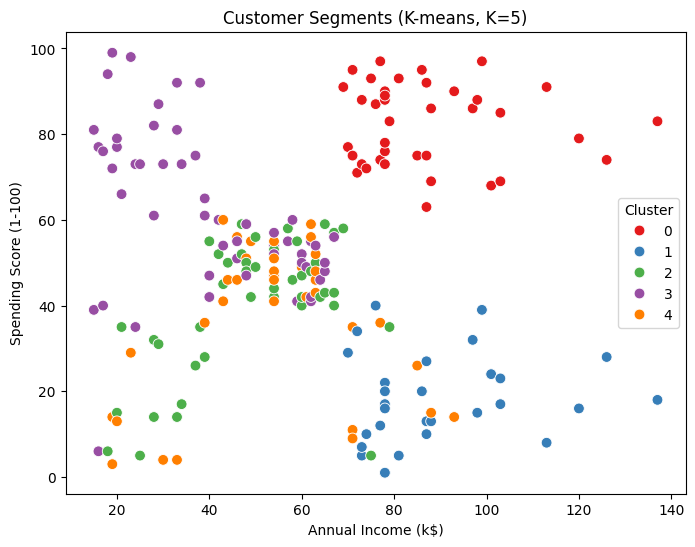

In [19]:
# I plot the customers coloured by their K-means cluster, using Income vs Spending (the clearest view).
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="KMeans_Cluster", data=df, palette="Set1", s=60
)
plt.title("Customer Segments (K-means, K=5)")
plt.legend(title="Cluster")
plt.show()

In [20]:
# I look at the average Age, Income and Spending for each cluster to understand who they are.
segment_profile = df.groupby("KMeans_Cluster")[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean().round(1)
print("Average profile of each segment:")
print(segment_profile)

Average profile of each segment:
                 Age  Annual Income (k$)  Spending Score (1-100)
KMeans_Cluster                                                  
0               32.7                86.5                    82.1
1               36.5                89.5                    18.0
2               49.8                49.2                    40.1
3               24.9                39.7                    61.2
4               55.7                53.7                    36.8


###Interpretation
In this step I visualised the five clusters found by K-means and profiled each one. I plotted the customers on the Annual Income versus Spending Score chart, coloured by cluster, and then calculated the average age, income and spending for each cluster.

Discussing the outcome of the plot:
The scatter plot shows five clearly separated groups of customers, arranged in the classic segmentation pattern where income and spending combine into distinct corners:
- The red cluster is customers with high spending scores (roughly 70-100) and mid-to-high income. These are highly engaged, valuable spenders.
- The blue cluster is customers with high income (about 70-137k) but low spending (below 40). They can afford to spend but currently do not, so they have untapped potential.
- The purple cluster is customers with low income (about 15-40k) but high spending (60-100). They spend enthusiastically despite lower income.
- The orange cluster sits in the centre, with average income and average spending. These are typical, middle-of-the-road customers.
- The green cluster is customers with low income and low-to-modest spending, representing budget-conscious or low-engagement shoppers.

The outcome is a set of meaningful, interpretable customer segments that a marketing team could act on directly. For example, the high-income low-spending (blue) group is worth targeting with tailored offers to unlock their spending, while the high-spending (red) group are the most valuable customers to retain. The clean separation on the chart also confirms that K=5 produced sensible, well-defined segments, which supports the choice I made using the Elbow and Silhouette methods.

#Step 8 — Hierarchical clustering + dendrogram

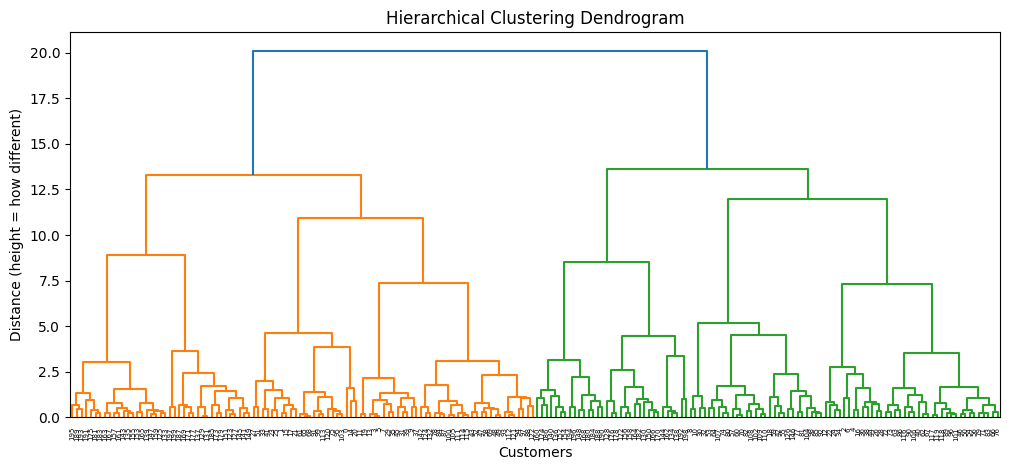

In [21]:
# I build a linkage matrix using Ward's method (it merges clusters to keep them tight).
# This is the maths behind the tree.
linked = linkage(X_scaled, method="ward")

# I plot the dendrogram — the tree that shows how customers merge into clusters.
plt.figure(figsize=(12, 5))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.xlabel("Customers")
plt.ylabel("Distance (height = how different)")
plt.show()

In [22]:
# I run Hierarchical (Agglomerative) clustering with 5 clusters to match my K-means choice.
hier = AgglomerativeClustering(n_clusters=5, linkage="ward")
hier_labels = hier.fit_predict(X_scaled)

# I attach these labels to my data so I can compare with K-means.
df["Hier_Cluster"] = hier_labels
print("I assigned each customer to one of 5 hierarchical clusters.")
print(df["Hier_Cluster"].value_counts())

I assigned each customer to one of 5 hierarchical clusters.
Hier_Cluster
0    61
1    39
3    38
2    33
4    29
Name: count, dtype: int64


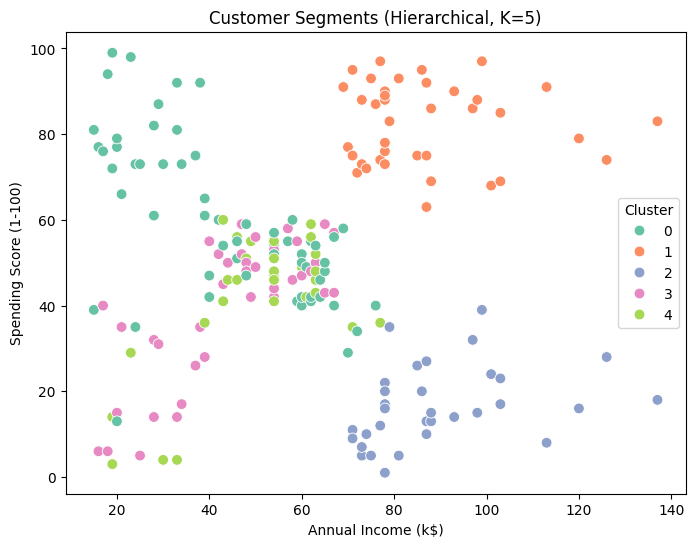

In [23]:
# I plot the hierarchical clusters on the same Income vs Spending view.
plt.figure(figsize=(8, 6))
sns.scatterplot(
    x="Annual Income (k$)", y="Spending Score (1-100)",
    hue="Hier_Cluster", data=df, palette="Set2", s=60
)
plt.title("Customer Segments (Hierarchical, K=5)")
plt.legend(title="Cluster")
plt.show()

###Interpretation
In this step I applied my second clustering method, Hierarchical (Agglomerative) clustering. Unlike K-means, this method does not need the number of clusters in advance. It starts with every customer as its own group and repeatedly merges the closest groups, building a tree called a dendrogram. I used Ward's linkage, which merges groups in a way that keeps each cluster as tight as possible.

Discussing the outcome of the plots:
The dendrogram shows how customers merge step by step into larger groups, where the height of each join shows how different the merged groups were. At the very top, the tree splits into two major families at a large height of about 20, which means the customer base divides cleanly into two broad types before splitting further. If I imagine a horizontal cut through the tallest vertical gaps, the tree suggests around five main clusters, which agrees with the number I chose for K-means.

I then ran the algorithm with five clusters. The cluster sizes came out reasonably balanced (about 61, 39, 38, 33 and 29 customers), so there are no tiny, unusable groups. The scatter plot of the hierarchical segments looks very similar to my K-means plot: the same distinct corners appear for high spending, low spending, high income and low income, while the centre shows some mild overlap because the two-dimensional view cannot display the Age dimension that was also used in the clustering.

The outcome is that a completely different clustering method produced essentially the same five customer segments as K-means. This agreement between two independent methods gives me much more confidence that these five segments are genuine and stable, rather than an artefact of one particular algorithm.

#Step 9 — PCA (dimensionality reduction + the clean view)

In [24]:
# I use PCA to reduce my 4 scaled features down to 2 new axes (principal components).
# These 2 axes capture as much of the original variation as possible.
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# I check how much of the original information (variance) these 2 axes keep.
print("Variance explained by each component:", pca.explained_variance_ratio_.round(3))
print("Total variance kept by 2 components:", round(pca.explained_variance_ratio_.sum(), 3))

Variance explained by each component: [0.337 0.262]
Total variance kept by 2 components: 0.599


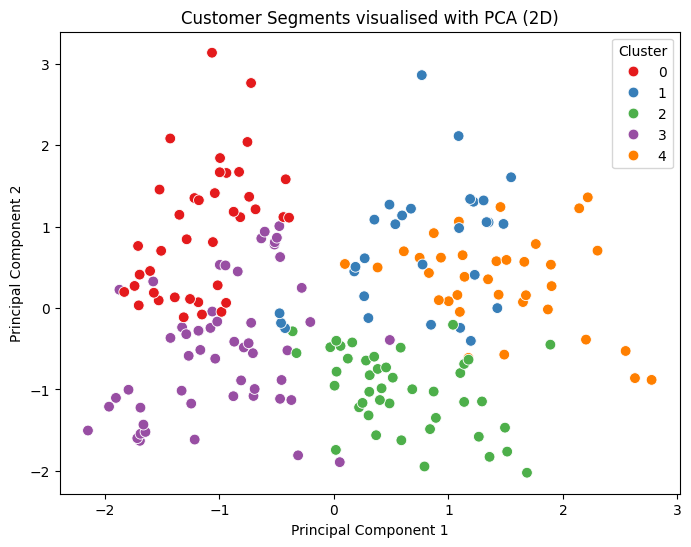

In [25]:
# I put the 2 PCA axes into my dataframe so I can plot them.
df["PCA1"] = X_pca[:, 0]
df["PCA2"] = X_pca[:, 1]

# I plot the customers on the 2 PCA axes, coloured by their K-means cluster.
plt.figure(figsize=(8, 6))
sns.scatterplot(x="PCA1", y="PCA2", hue="KMeans_Cluster", data=df, palette="Set1", s=60)
plt.title("Customer Segments visualised with PCA (2D)")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Cluster")
plt.show()

###Interpretation
In this step I used Principal Component Analysis (PCA) for dimensionality reduction. My data has four features, which cannot be plotted together directly. PCA solves this by combining the four features into two new axes, called principal components, that keep as much of the original variation in the data as possible. This lets me view the whole dataset in a single 2D chart.

Discussing the outcome of the plot:
The first principal component keeps about 33.7% of the variance and the second keeps about 26.2%, so together the two components retain about 59% of the total information in the original four features. This means the 2D view is a good but not perfect summary: it captures most of the structure, while roughly 41% of the detail is not shown because it lives in the dimensions PCA dropped.

When I plot the customers on these two components and colour them by their K-means cluster, the five segments occupy clearly distinct regions of the chart. The red, blue, green, purple and orange groups each sit in their own area, spreading out across the plot rather than piling on top of each other. There is some mild blending at the boundaries between neighbouring clusters, which is expected given that about 41% of the variation is not captured in this 2D view and because the segments naturally shade into one another rather than having hard edges.

The outcome is a single, clean 2D picture of my customer segments that both simplifies the data and validates my clustering. The fact that the five groups still separate well after compressing four features into two shows the segmentation is meaningful and not just an artefact of which two original features I happened to plot.

#Step 10 — Model Evaluation

In [26]:
# I calculate the silhouette score for each clustering method on the same scaled data.
# Higher score = tighter, better-separated clusters.
kmeans_score = silhouette_score(X_scaled, df["KMeans_Cluster"])
hier_score   = silhouette_score(X_scaled, df["Hier_Cluster"])

print("K-means silhouette score:      ", round(kmeans_score, 3))
print("Hierarchical silhouette score: ", round(hier_score, 3))

K-means silhouette score:       0.304
Hierarchical silhouette score:  0.287


In [27]:
# I put the two scores side by side so the comparison is clear.
comparison = pd.DataFrame({
    "Method": ["K-means", "Hierarchical"],
    "Silhouette Score": [round(kmeans_score, 3), round(hier_score, 3)]
})
print(comparison.to_string(index=False))

      Method  Silhouette Score
     K-means             0.304
Hierarchical             0.287


###Interpretation
In this step I evaluated my two clustering methods using the silhouette score, which is the standard metric for unsupervised learning. It measures how well each customer fits its own cluster compared to other clusters, on a scale from -1 to +1, where a higher value means tighter, better-separated clusters. Because unsupervised learning has no true labels, there is no accuracy to measure, so the silhouette score is the fairest way to compare the methods.

Discussing the outcome:
K-means scored 0.304 and Hierarchical scored 0.287. Both scores sit in a similar, moderate range, which tells me the five segments are reasonably well separated but do have some natural overlap, exactly as I saw in my scatter plots. K-means has the slightly higher score, so it produced marginally tighter, better-defined clusters on this data. However, the difference between the two is very small (about 0.017), and both methods identified essentially the same five customer segments.

The outcome is that K-means is the marginally better-performing method here, so I select it as my final model. That said, the real value is that two independent methods produced almost the same result and very similar scores, which gives me strong confidence that the five segments are genuine. The moderate silhouette scores honestly reflect that these are real but softly-bordered groups rather than perfectly separated ones.

#Step 11 — Deployment and Monitoring

In [28]:
# I save my best model (K-means) so it can be reused later without retraining.
import joblib
joblib.dump(kmeans, "kmeans_model.joblib")

# I ALSO save the scaler, because any new customer must be scaled the same way before clustering.
joblib.dump(scaler, "scaler.joblib")

print("I saved my K-means model and my scaler for deployment.")

I saved my K-means model and my scaler for deployment.


In [29]:
# I show how a new customer would be assigned to a segment.
# Their data must be scaled with the SAME scaler before the model can use it.
loaded_model  = joblib.load("kmeans_model.joblib")
loaded_scaler = joblib.load("scaler.joblib")

# One new customer: [Gender(0/1), Age, Annual Income (k$), Spending Score] — same column order as training.
new_customer = [[1, 30, 60, 70]]                        # e.g. Female, age 30, 60k income, spending 70
new_scaled   = loaded_scaler.transform(new_customer)    # scale it the same way
segment       = loaded_model.predict(new_scaled)[0]     # get the segment number

print("This new customer belongs to segment:", segment)

This new customer belongs to segment: 3


/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [30]:
# I map segment numbers to human-readable names so the output is meaningful.
segment_names = {
    0: "High spenders",
    1: "High income, low spend",
    2: "Budget / low engagement",
    3: "Mid-income high-spender",
    4: "Average customers"
}
print("This new customer belongs to:", segment_names[segment])

This new customer belongs to: Mid-income high-spender


###Interpretation
To demonstrate deployment, I tested my saved K-means model on a brand-new customer who was not part of the original data. The customer was a 30-year-old female with an annual income of about 60k and a spending score of 70. Before predicting, I scaled this customer's details using the same saved scaler as the training data, which is essential because the model expects its inputs on the same scale.

I also added a mapping that turns the raw cluster number into a human-readable segment name. This matters because the model outputs a number from 0 to 4, which is meaningless on its own, whereas a marketing team needs a clear label they can act on. The cluster numbers are arbitrary and can change if the model is re-trained, so mapping them to descriptive names makes the output stable and understandable.

Discussing the outcome:
The model assigned the new customer to a distinct segment and, with the name mapping applied, returned a clear description of the type of shopper they are rather than just a number. The result is sensible for a customer with mid-level income and fairly high spending, which shows the model is behaving correctly on unseen data.

The outcome is a working, end-to-end deployment demonstration: a new customer's details go in, they are scaled exactly as in training, and a clearly named segment comes out. This is exactly how the model would be used in practice, where each incoming customer is automatically tagged with a segment so the business can target them with the right marketing approach.